In [12]:
n,m = 400,90 #punto de observación (X,h)
fila = 22 ## fila de perfil del cerro 
directorio = '/home/cesarc/Work/test2/'
#directorio = '/home/cesarc/Work/split_files3/'

In [13]:
import numpy as np
import csv
import math 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
import os

#import sys

file_raster = './rastert_dem_uni1-clean.txt' ## DEM file 
#file_shower_txt = './energia_split_data_3.txt' ## file de energía
#file_shower_txt = '~/Work/split_files3/Dlim-2201-01_08640007.txt' ## file de energía

#file_shower_folder = '~/Work/test2/' ## file de energía

fila = 22 ## (por qué?)
escala_satelite = 3 # escala en X de acuerdo a datos de CONIDA (unidades?)
angle_observation = 270 # ángulo phi de observación en coordenadas de CORSIKA

phi1, phi2 = 269, 271 #posición de observación en coordenadas de CORSIKA
anglet = 3 #apertura en azimutal
arr_z_cerro = []
pt_ob = [n,m] #punto de observación (300,120) -> (x,h)

## inicio del programa 
cmap = plt.colormaps['viridis']
num_colors = 40
color = cmap(np.linspace(0, 1, num_colors))

## línea de visión 
def recta(x_0, y_0, x, angulo): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    y_recta= y_0+np.tan(np.radians(angulo))*(x-x_0)     

    return y_recta,  


def pendiente_recta(X_0, X): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    m = (y[1]-y_0[1])/(x[0]-x_0[0])

    return m  

def pendiente_recta(X_0, X): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    m2 = (X[1]-X_0[1])/(X[0]-X_0[0])

    return m2  

def distancia_d(p1, p2):

    distancia_interna= math.sqrt((p2[1]-p1[1])**2 + ((p2[0]-p1[0])*escala_satelite)**2) 
    
    return distancia_interna


############################ 
# calcula el p0
# compara el array del cerro con la recta y da el valor de intersección
# pt_ob = (pt_obx, pt_oby) , array = valor en y del objeto cerro , array_recta = valores de y de la recta en la
# array_x = valores en x
# dirección de observación 

def pto_0(pt_ob, array_x, array): 
    for i in range(pt_ob[0], len(array_x)):
        if pto_0[1]==array[i]: 
            pto_inicial= i
    return (pto_inicial, pto_0[1])


def indice_cruce(pt_ob, array_x, array_cerro, array_recta, tipo='primer'):  
    """
    Encuentra el índice de cruce en un arreglo.

    Parámetros:
    pt_ob -- Un valor de referencia para comenzar la búsqueda.
    array_x -- Lista de valores de x.
    array_cerro -- Lista de valores de la línea del cerro.
    array_recta -- Lista de valores de la recta.
    tipo -- Puede ser 'primer' para el primer cruce o 'segundo' para el segundo cruce.

    Retorna:
    Una tupla con el índice de cruce y el valor correspondiente del array_cerro.
    """
    # Definir el índice de cruce
    indice = -1

    # Realizar la búsqueda dependiendo del tipo
    if tipo == 'primer':
        # Buscar el primer cruce
        for i in range(0, pt_ob[0]):
            if (array_recta[i] - array_cerro[i]) < 0:
                indice = i
                break
    elif tipo == 'segundo':
        # Buscar el último cruce
        for i in range(pt_ob[0], len(array_x)):
            if (array_recta[i] - array_cerro[i]) < 0:
                indice = i

    if indice != -1:
        
        return (indice, array_cerro[indice])
    else:
        return None  # Si no se encuentra ningún cruce
     
def distancia(p1, p2): #distancia entre dos puntos 
 
    dist = math.sqrt((p2[1]-p1[1])**2 + ((p2[0]-p1[0])*escala_satelite)**2)  
    return dist  

## CÁLCULO DEL LA ELEVACIÓN MÁXIMA DE OBSERVACION


def angulo_maximo(arr_x, np_array, p): #arra_x: indices en el eje X, fila: fila de analisis, p: punto de observación 
        vec_picos = []
        vec  = []
        ind_z = 0 
        ind_x = 0 
    
        for j in range(p[0], len(arr_x)): 
            if np_array[j] > ind_z:
                ind_z = np_array[j]
                ind_x = j 
    
        vec_picos.append(ind_x)
        vec_picos.append(ind_z)

        h_max = ind_z-p[1]
        x_max = arr_x[ind_x]-p[0]  
    
        phi_max = np.degrees(np.arctan2(h_max,x_max))

#        print(ind_z,ind_x,h_max,x_max,phi_max)
    
        return (vec_picos, phi_max) #ángulo en grados
    
#ecuaciones de pérdida de energía 

def funciondEdX_lesparre(E):  
    l4 = 0.0154 
    l3 = -0.0461 
    l2 = 0.0368
    l1 = 0.0801
    l0 = 0.2549
    y = math.log10(E)
    dEdx = 10**(l4*y**4+l3*y**3+l2*y**2+l1*y**1+l0)
    
    return dEdx
        

def funciondEdX_tesis(E): 
    me = 0.0005285 #GeV/c2
    mu = 0.1057 #GeV/c2
    
    Emax = (E**2)/(E+(mu**2)/(2*me))
    dEdx = (1.84 + 0.076* np.log(Emax/(mu)))
     
    return dEdx
        
#################################  

def perdida_energia_total(E, d): #energia y distancia por recorrer segun lesparre

    E = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3
    control = False

#    print("Initial parameters (Lesparre) - Energy:",E,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades ) 
        j=j+1
        dE_dx = funciondEdX_lesparre(E)
        energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
        E = E - energy_loss
        print(E)
        if E < 0 : 
            control = False
            break 
        control = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final = E 
    
    return (energia_final, control)
    #Control True = pasó, False = no pasó

#################################  

def perdida_energia_total_hueco(E, d): #energia y distancia por recorrer segun lesparre

    E = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3
    control = False

#    print("Initial parameters (Lesparre) - Energy:",E,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades ) 
        j=j+1
        dE_dx = funciondEdX_lesparre(E)
        
        if j < round(4*d/10):         
            energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
        if j > round(4*d/10)+1 or j < round(6*d/10): 
            energy_loss = 0 # Energy loss in the step with no material
        if j > round(6*d/10)+1: 
            energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
            
        E = E - energy_loss
    
        if E < 0 : 
            control = False
            break 
        control = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final = E  
  
    
    return (energia_final, control)
    #Control True = pasó, False = no pasó

################################

def perdida_energia_total_tesis(E, d): #energia y distancia por recorrer segun lesparre

    E_t = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Tesis) - Energy:",E_t,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades 
        j=j+1
        dE_dx_t = funciondEdX_tesis(E_t)
        energy_loss_t = dE_dx_t * step_size * avg_dens # Energy loss in the step        
        E_t = E_t - energy_loss_t
    
        if E_t < 0 : 
            control_t = False
            break 
        control_t = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final_t = E_t 
    
    return (energia_final_t, control_t)
    #Control True = pasó, False = no pasó

#################################  
   
## Diccionario de distancias 
 

def acceder_diccionario(diccionario, valor_clave):
    # Inicializar variables para el valor más cercano y la distancia mínima
    valor_mas_cercano = None
    distancia_minima = float('inf')
    
    for clave, valor in diccionario.items():
        # Calcular la distancia entre el valor_clave y el valor actual del diccionario
        distancia_actual = abs(valor_clave - clave)
        # Si encontramos una distancia menor, actualizamos el valor más cercano
        if distancia_actual < distancia_minima:
            distancia_minima = distancia_actual
            valor_mas_cercano = valor
    
    return valor_mas_cercano



def reducir_vector_por_media(vector, num_intervals=11):
    """
    Reduce un vector a un número menor de valores calculando la media 
    de cada intervalo.
    
    Args:
    - vector (list o np.ndarray): Vector de entrada con más de 10,000 valores.
    - num_intervals (int): Número de valores que tendrá el vector reducido.
    
    Returns:
    - np.ndarray: Vector reducido con `num_intervals` valores.
    """
    # Asegúrate de que el vector es un array de numpy para facilitar el manejo
    vector = np.array(vector)
    n = len(vector)
    
    # Determina el tamaño de cada intervalo
    interval_size = n // num_intervals
    
    # Crea un vector reducido calculando la media de cada intervalo
    reduced_vector = [
        np.mean(vector[i * interval_size:(i + 1) * interval_size])
        for i in range(num_intervals)
    ]
    
    return np.array(reduced_vector)

def pendiente_recta(X_0, X): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    m = (X[1]-X_0[1])/(X[0]-X_0[0])

    return m  

def distancia_d(p1, p2):

    distancia_interna= math.sqrt((p2[1]-p1[1])**2 + ((p2[0]-p1[0])*escala_satelite)**2) 
    
    return distancia_interna


class RasterData:
    def __init__(self, file_path):
        """
        Inicializa el objeto RasterData cargando los datos desde un archivo.
        
        :param file_path: Ruta al archivo CSV del raster.
        """
        self.file_path = file_path
        self.data = self._load_data()
        self.n_cols = self.data.shape[1]
        self.n_rows = self.data.shape[0]
    
    def _load_data(self):
        """
        Carga los datos desde el archivo CSV, rellena los valores faltantes con 0 
        y elimina la última columna.
        
        :return: DataFrame procesado.
        """
        df = pd.read_csv(self.file_path, sep=" ", header=None)
        df = df.fillna(0)
        if df.shape[1] > 0:  # Verifica que haya columnas antes de eliminar
            df = df.drop(columns=df.shape[1] - 1)


        return df 
    
    def get_dimensions(self):
        """
        Devuelve las dimensiones del raster.
        
        :return: Tupla (n_filas, n_columnas).
        """
        return self.n_rows, self.n_cols
    
    def preview_data(self, rows=5):
        """
        Devuelve una vista previa de los datos del raster.
        
        :param rows: Número de filas a mostrar.
        :return: Vista previa del DataFrame.
        """
        return self.data.head(rows)
    


# Función para calcular mallas y coordenadas
def generate_semicircle_data(radius_inner, radius_outer, data):
    theta, r = np.meshgrid(angles, np.linspace(radius_inner, radius_outer, 2))
    X = r * np.cos(theta)
    Y = r * np.sin(theta)
    Z = np.tile(data, (2, 1))
    return X, Y, Z




In [5]:
# Inicializa el objeto con el archivo CSV 
raster = RasterData(file_raster)
# Obtén dimensiones
n_col = raster.get_dimensions()[1] 
raster = RasterData(file_raster)
arr_z_cerro = raster._load_data().iloc[fila].to_numpy() #elevación del cerro en una determinada fila
arr_x = np.linspace(0,n_col-1,n_col) #crea los índices en x (n_col) para iterar  
ang_max = int(np.round(angulo_maximo(arr_x, arr_z_cerro, pt_ob)[1])) #ángulo máximo de observación para una fila 
# Ruta del directorio que quieres recorrer
 

# de archivo 1
# de archivo 2
# de archivo 3
# de archivo 4
# de archivo 5
# de archivo 6
# de archivo 7
# de archivo 8
# de archivo 9
# de archivo 10
# de archivo 11
# de archivo 12
# de archivo 13
# de archivo 14
# de archivo 15
# de archivo 16
# de archivo 17
# de archivo 18
# de archivo 19
# de archivo 20
# de archivo 21
# de archivo 22
# de archivo 23
# de archivo 24
# de archivo 25
# de archivo 26
# de archivo 27
# de archivo 28
# de archivo 29
# de archivo 30
# de archivo 31
# de archivo 32
# de archivo 33
# de archivo 34
# de archivo 35
# de archivo 36
# de archivo 37
# de archivo 38
# de archivo 39
# de archivo 40
# de archivo 41
# de archivo 42
# de archivo 43
# de archivo 44
# de archivo 45
# de archivo 46
# de archivo 47
# de archivo 48
# de archivo 49
# de archivo 50
# de archivo 51
# de archivo 52
# de archivo 53
# de archivo 54
# de archivo 55
# de archivo 56
# de archivo 57
# de archivo 58
# de archivo 59
# de archivo 60
# de archivo 61
# de archivo 62
# de archivo 63
#

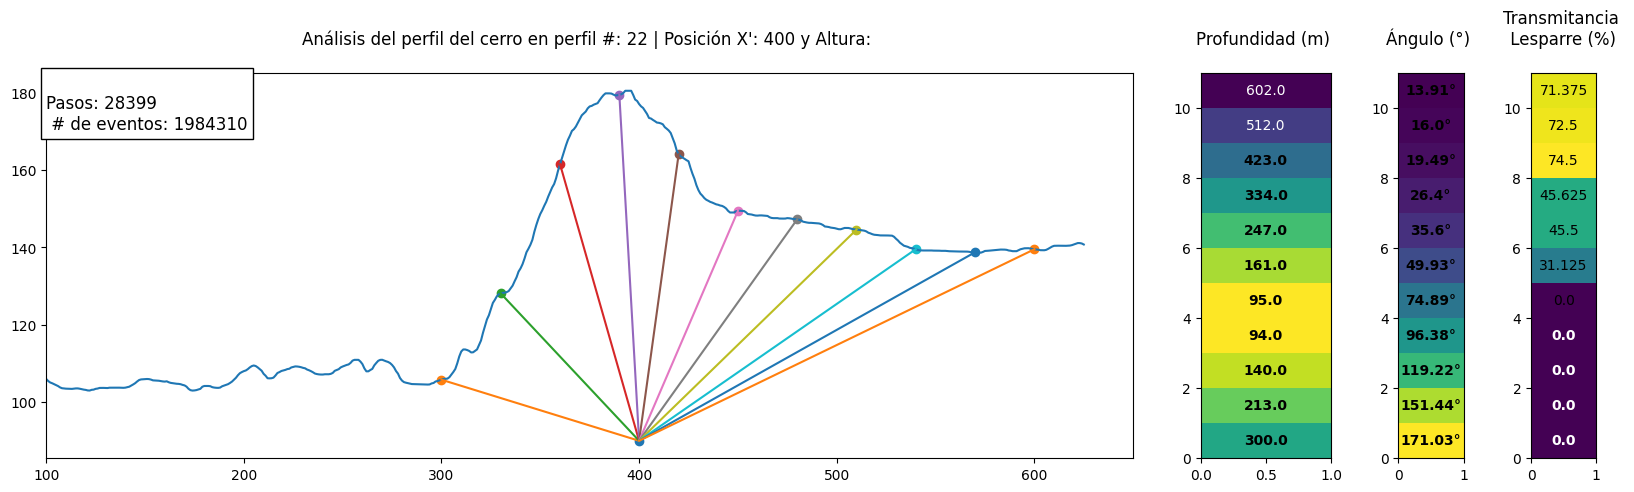

In [8]:
#fig, axs = plt.subplots(1, 5,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3,0.3]})  # 2 filas, 1 columna de subplots
fig, axs = plt.subplots(1, 4,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3]})  # 2 filas, 1 columna de subplots
pasos_en_grafica = 30

####################################################################################################
#PLOT 0 del perfil UNI y puntos de intersección 
############ 
axs[0].plot(arr_z_cerro)
axs[0].scatter(pt_ob[0], pt_ob[1])
 
#coordenadas (x,h) de intersección entre la proyección de observación y el perfil del cerro, para cada ángulo analizado
vec_dis=[] #vector con la fila, el ángulo de observación y la profundidad
j=0
p2_max = 0
axs[0].set_title("Análisis del perfil del cerro en perfil #: "+ str(fila)+" | Posición X': "+str(n)+" y Altura: \n") 
 
vec_pts_sup,  vec_angles  , vec_distancia_raster = [] , [], [] 


index_i = 300 #inicializacion 
for i in range(index_i, len(arr_z_cerro), pasos_en_grafica):  
      
    angulo_m = math.degrees(np.arctan(pendiente_recta(pt_ob, [i, arr_z_cerro[i]])))
    
    if angulo_m < 0: 
       
        angulo_m = angulo_m +180
    
    axs[0].plot([pt_ob[0], i],[pt_ob[1], arr_z_cerro[i]])#, color=color[i])    
    axs[0].scatter(i, arr_z_cerro[i]) 
    evento = [fila,round(angulo_m,2),distancia_d(pt_ob,[i, arr_z_cerro[i]])]  #los valores registrados son azimutales, los valores en el plot son elevación
    vec_dis.append(evento)  # fila, th_i angulo de observación, distancia 
    
    
#######################################################----------------------------#
### Creacion de diccionario 

diccionario = {}  # Inicializar el diccionario vacío
#Recordar que vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves para cada uno de los ángulos
    clave = round(vec_dis[i][1],0) #valores de ángulo
    valor = round(vec_dis[i][2],0) #valores de distancia
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  

    
### Registra distancias para los angulos disponibles 

a_vec_dis=[] #vector con los valores de profundidad desde un punto de observación dado por vec_dis. 
for i in range(len(vec_dis)):
    r = vec_dis[i][2] #registra solo la distancia 
    a_vec_dis.append(np.round(r,0))

a_vec_dis = np.array(a_vec_dis) #registra las distancias de los ángulos disponibles para la observación desde un punto de observación 
a_vec_dis = a_vec_dis[::-1] #ordena de menor a mayor 


#######################################################----------------------------#
### Vector con los valores de ángulo tomada de vec dis
b_vec_dis=[] #vector con los valores de profundidad tomada de vec_dis
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    rr = vec_dis[i][1] #registra solo los ángulos 
    b_vec_dis.append(np.round(rr,2))

b_vec_dis = np.array(b_vec_dis)
b_vec_dis=b_vec_dis[::-1] 

matriz = np.tile(a_vec_dis, (1,1))
matriz_rotada_distancias_observacion = np.rot90(matriz)
 

########################################################################################################## 
#PLOT 1 de la distancia
############ 

axs[1].set_title("Profundidad (m) \n")

im = axs[1].pcolormesh(matriz_rotada_distancias_observacion,cmap="viridis_r")

for i in range(matriz_rotada_distancias_observacion.shape[0]):
    for j in range(matriz_rotada_distancias_observacion.shape[1]): 
        if i <= 8:         
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), fontweight='bold',  color='black', ha='center', va='center')
        else: 
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), color='white', ha='center', va='center')


 
 
#PLOT 2: Ángulos de observación de ángulos diferente de 0 
############

matriz_2 = np.tile(b_vec_dis, (1,1))
matriz_rotada_angulos_observacion = np.rot90(matriz_2)

axs[2].set_title("Ángulo (°) \n")

io = axs[2].pcolormesh(matriz_rotada_angulos_observacion,cmap="viridis")

for i in range(matriz_rotada_angulos_observacion.shape[0]):
    for j in range(matriz_rotada_angulos_observacion.shape[1]):
        if i <= 5:         
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°', fontweight='bold',color='black', ha='center', va='center')
        else: 
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°',  fontweight='bold',color='black', ha='center', va='center')

################################################
## Cálculo de la atenuación por cada archivo
################################################


#####################################################
########### LOOP SOBRE TODOS LOS ARCHIVOS ###########

veco=[] #array con los valores de phi , theta, distancia recorrida, Einicial, Efinal, Control
angulos_atenuados = []
veco_tesis  = []

 


conteo_archivo = 0 
# Recorremos todos los archivos en el directorio
for nombre_archivo in os.listdir(directorio):
    # Construimos la ruta completa al archivo
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    conteo_archivo= conteo_archivo+1
    
    # Verificamos si es un archivo (y no una carpeta)
    if os.path.isfile(ruta_archivo):
        # Abrimos y leemos el archivo 

        with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
             # Aquí puedes procesar el contenido como necesites 

            df_shower  = pd.read_csv(ruta_archivo, sep =" ")# Lee los datos del shower en energia y ángulo
            data_shower = df_shower.sort_values(by=df_shower.columns[1]) #data ordered by phi angle
            #dfshower_pre_filtrado = data_shower#[ (data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)] #data selected by theta angle limits
            dfshower_pre_filtrado = data_shower[ (data_shower['phit'] >= phi1) & (data_shower['phit'] <= phi2) ] #data selected by theta angle limits

            ## ACA FILTRAR POR PHI 
            ## ACA FILTRAR POR PHI 
            ## ACA FILTRAR POR PHI 
            ## ACA FILTRAR POR PHI 
            dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 
            conteo_evento = 0 

            for j in range(len(dfshower_filtrado)):  
                #if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
                angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
                temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
                temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
                    
                temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################
            
                 
                fin_ener, val_temp = perdida_energia_total(temp_energia_shower, round(temp_distancia_x_angulo)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
                res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
                veco.append(res_atenua)
                    
                    
                conteo_evento = conteo_evento +1       

    print("# de archivo", conteo_archivo)

print("Total de archivos procesados = ", conteo_archivo) 
print("# de eventos = ", conteo_evento) 

print("=============") 

#######################################################----------------------------#
### Grafica final de Plot 0

texto = '\nPasos: '+ str(j) +'\n # de eventos: '+ str(len(veco))
x_pos = 100 # valor 20 de posición de texto en X
y_pos = np.max(arr_z_cerro) -10 # valor de posición de caja de texto en Y 
axs[0].text(x_pos, y_pos, texto,fontsize = '12', bbox=dict(facecolor='white', edgecolor='black', linewidth=1))
axs[0].set_xlim(100,650) 
#axs[0].set_ylim(110, np.max(arr_z_cerro)+20)


########### END LOOP SOBRE TODOS LOS ARCHIVOS ###########
#########################################################

#################
#Pérdida de energía de acuerdo a Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

## Reducir los valores ###
 
vector_reducido = reducir_vector_por_media(vec_atenuado)

 


################################################
## Fin del cálculo de la atenuación
################################################
## Calculamos el porcentaje de atenuación

data_porcentaje = np.array(vec_angle)

########################################################################################################## 
#PLOT 3
############
data_angle = np.array(vector_reducido)
data_angle=data_angle[::-1] 
matriz_3 = np.tile(data_angle, (1,1))
matriz_rotada_3 = matriz_3
matriz_rotada_3 = np.rot90(matriz_3) 

axs[3].set_title("Transmitancia \n Lesparre (%) \n")

iu = axs[3].pcolormesh(matriz_rotada_3,cmap="viridis")

for i in range(matriz_rotada_3.shape[0]):
    for j in range(matriz_rotada_3.shape[1]): 
        if i <= 3:         
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), fontweight='bold', color='white', ha='center', va='center')
            
        else: 
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), color='black', ha='center', va='center')
          
 
#plt.savefig("Análisis del perfil del cerro en X_"+str(n)+ "_Z_"+ str(m)+ "_Y_"+ str(fila)+".png" )
 
plt.show()



# de archivo 1
# de archivo 2
# de archivo 3
# de archivo 4
# de archivo 5
# de archivo 6
# de archivo 7
# de archivo 8
# de archivo 9
# de archivo 10
# de archivo 11
# de archivo 12
# de archivo 13
# de archivo 14
# de archivo 15
# de archivo 16
# de archivo 17
# de archivo 18
# de archivo 19
# de archivo 20
# de archivo 21
# de archivo 22
# de archivo 23
# de archivo 24
# de archivo 25
# de archivo 26
# de archivo 27
# de archivo 28
# de archivo 29
# de archivo 30
# de archivo 31
# de archivo 32
# de archivo 33
# de archivo 34
# de archivo 35
# de archivo 36
# de archivo 37
# de archivo 38
# de archivo 39
# de archivo 40
# de archivo 41
# de archivo 42
# de archivo 43
# de archivo 44
# de archivo 45
# de archivo 46
# de archivo 47
# de archivo 48
# de archivo 49
# de archivo 50
# de archivo 51
# de archivo 52
# de archivo 53
# de archivo 54
# de archivo 55
# de archivo 56
# de archivo 57
# de archivo 58
# de archivo 59
# de archivo 60
# de archivo 61
# de archivo 62
# de archivo 63
#

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


# de archivo 70
Total de archivos procesados =  70
# de eventos =  28400


/tmp/ipykernel_11611/1814950293.py:251: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[0].pcolormesh(X1, Y1, Z1, cmap="viridis_r", shading="auto")
/tmp/ipykernel_11611/1814950293.py:253: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[0].pcolormesh(X2, Y2, Z2, cmap="plasma", shading="auto")
/tmp/ipykernel_11611/1814950293.py:255: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
 

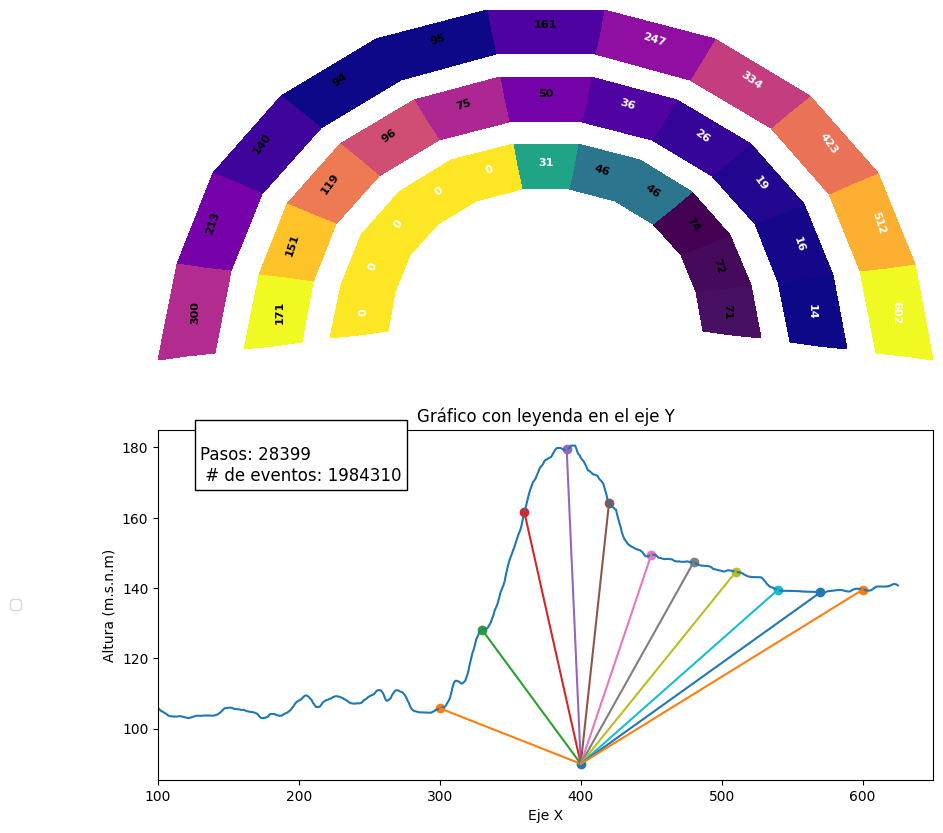

In [9]:
#fig, axs = plt.subplots(1, 5,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3,0.3]})  # 2 filas, 1 columna de subplots
fig, axs = plt.subplots(nrows=2, ncols=1,figsize=(10,10), gridspec_kw={'height_ratios': [1, 1]} )  # 2 filas, 1 columna de subplots
pasos_en_grafica = 30

####################################################################################################
#PLOT 0 del perfil UNI y puntos de intersección 
############ 
axs[1].plot(arr_z_cerro)
axs[1].scatter(pt_ob[0], pt_ob[1])
 
#coordenadas (x,h) de intersección entre la proyección de observación y el perfil del cerro, para cada ángulo analizado
vec_dis=[] #vector con la fila, el ángulo de observación y la profundidad
j=0
p2_max = 0
axs[1].set_title("Análisis del perfil del cerro en perfil #: "+ str(fila)+" | Posición X': "+str(n)+" y Altura: \n") 
 
vec_pts_sup,  vec_angles  , vec_distancia_raster = [] , [], []
index_i = 300 #inicializacion 
for i in range(index_i, len(arr_z_cerro), pasos_en_grafica):  
      
    angulo_m = math.degrees(np.arctan(pendiente_recta(pt_ob, [i, arr_z_cerro[i]])))
     
    if angulo_m < 0: 
       
        angulo_m = angulo_m +180
    
    
    axs[1].plot([pt_ob[0], i],[pt_ob[1], arr_z_cerro[i]])# , color=color[j])    
    axs[1].scatter(i, arr_z_cerro[i]) 
    evento = [fila,round(angulo_m),distancia_d(pt_ob,[i, arr_z_cerro[i]])]  #los valores registrados son azimutales, los valores en el plot son elevación
    vec_dis.append(evento)  # fila, th_i angulo de observación, distancia 
    
    
#######################################################----------------------------#
### Creacion de diccionario 

diccionario = {}  # Inicializar el diccionario vacío
#Recordar que vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves para cada uno de los ángulos
    clave = round(vec_dis[i][1],0) #valores de ángulo
    valor = round(vec_dis[i][2],0) #valores de distancia
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  

    
### Registra distancias para los angulos disponibles 

a_vec_dis=[] #vector con los valores de profundidad desde un punto de observación dado por vec_dis. 
for i in range(len(vec_dis)):
    r = vec_dis[i][2] #registra solo la distancia 
    a_vec_dis.append(np.round(r,0))

a_vec_dis = np.array(a_vec_dis) #registra las distancias de los ángulos disponibles para la observación desde un punto de observación 
a_vec_dis = a_vec_dis[::-1] #ordena de menor a mayor
 


#######################################################----------------------------#
### Vector con los valores de ángulo tomada de vec dis
b_vec_dis=[] #vector con los valores de profundidad tomada de vec_dis
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    rr = vec_dis[i][1] #registra solo los ángulos 
    b_vec_dis.append(np.round(rr,2))

b_vec_dis = np.array(b_vec_dis)
b_vec_dis=b_vec_dis[::-1] 

matriz = np.tile(a_vec_dis, (1,1))
matriz_rotada_distancias_observacion = np.rot90(matriz)

 


########################################################################################################## 
#PLOT 1 de la distancia
############ 

'''
axs[1].set_title("Profundidad (m) \n")
im = axs[1].pcolormesh(matriz_rotada_distancias_observacion,cmap="viridis_r")
for i in range(matriz_rotada_distancias_observacion.shape[0]):
    for j in range(matriz_rotada_distancias_observacion.shape[1]): 
        if i <= 8:         
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), fontweight='bold',  color='black', ha='center', va='center')
        else: 
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), color='white', ha='center', va='center')
'''

 
 
#PLOT 2: Ángulos de observación de ángulos diferente de 0 
############

matriz_2 = np.tile(b_vec_dis, (1,1))
matriz_rotada_angulos_observacion = np.rot90(matriz_2)
'''
axs[2].set_title("Ángulo (°) \n")

io = axs[2].pcolormesh(matriz_rotada_angulos_observacion,cmap="viridis")

for i in range(matriz_rotada_angulos_observacion.shape[0]):
    for j in range(matriz_rotada_angulos_observacion.shape[1]):
        if i <= 5:         
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°', fontweight='bold',color='black', ha='center', va='center')
        else: 
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°',  fontweight='bold',color='black', ha='center', va='center')
'''

################################################
## Cálculo de la atenuación por cada archivo
################################################


#####################################################
########### LOOP SOBRE TODOS LOS ARCHIVOS ###########

veco=[] #array con los valores de phi , theta, distancia recorrida, Einicial, Efinal, Control
angulos_atenuados = []
veco_tesis  = []

 


conteo_archivo = 0 
# Recorremos todos los archivos en el directorio
for nombre_archivo in os.listdir(directorio):
    # Construimos la ruta completa al archivo
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    conteo_archivo= conteo_archivo+1
    
    # Verificamos si es un archivo (y no una carpeta)
    if os.path.isfile(ruta_archivo):
        # Abrimos y leemos el archivo 

        with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
             # Aquí puedes procesar el contenido como necesites 

            df_shower  = pd.read_csv(ruta_archivo, sep =" ")# Lee los datos del shower en energia y ángulo
            data_shower = df_shower.sort_values(by=df_shower.columns[1]) #data ordered by phi angle
            dfshower_pre_filtrado = data_shower[ (data_shower['phit'] >= phi1) & (data_shower['phit'] <= phi2)] #data selected by phi angle limits
            dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 
            conteo_evento = 0 

            for j in range(len(dfshower_filtrado)):  
                #if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
                angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
                temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
                temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
                    
                temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################
            
                 
                fin_ener, val_temp = perdida_energia_total(temp_energia_shower, round(temp_distancia_x_angulo)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
                res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
                veco.append(res_atenua)
                    
                    
                conteo_evento = conteo_evento +1       

    print("# de archivo", conteo_archivo)

print("Total de archivos procesados = ", conteo_archivo) 
print("# de eventos = ", conteo_evento) 

print("=============") 

#######################################################----------------------------#
### Grafica final de Plot 0

texto = '\nPasos: '+ str(j) +'\n # de eventos: '+ str(len(veco))
x_pos = 130 # valor 20 de posición de texto en X
y_pos = np.max(arr_z_cerro) -10 # valor de posición de caja de texto en Y 
axs[1].text(x_pos, y_pos, texto,fontsize = '12', bbox=dict(facecolor='white', edgecolor='black', linewidth=1))
axs[1].set_xlim(100,650) 
axs[1].legend(loc="center left", bbox_to_anchor=(-0.2, 0.5))  # Ajustar la posición con bbox_to_anchor
# Títulos y etiquetas
axs[1].set_title("Gráfico con leyenda en el eje Y")
axs[1].set_xlabel("Eje X")
axs[1].set_ylabel("Altura (m.s.n.m)")

#axs[0].set_ylim(110, np.max(arr_z_cerro)+20)


########### END LOOP SOBRE TODOS LOS ARCHIVOS ###########
#########################################################

#################
#Pérdida de energía de acuerdo a Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

## Reducir los valores ###
 
vector_reducido = reducir_vector_por_media(vec_atenuado)

 


################################################
## Fin del cálculo de la atenuación
################################################
## Calculamos el porcentaje de atenuación

data_porcentaje = np.array(vec_angle)

########################################################################################################## 
#PLOT 3
############
data_angle = np.array(vector_reducido)
data_angle=data_angle[::-1] 
matriz_3 = np.tile(data_angle, (1,1))
matriz_rotada_3 = matriz_3
matriz_rotada_3 = np.rot90(matriz_3) 
 
 
##Crear listas de datos para ambas franjas semicirculares
data_angle1 = data_angle  # Datos para la transmitancia 
data_angle2 = b_vec_dis  # Datos para los ángulos
data_angle3 = a_vec_dis  # Datos para las distancias 

n_points = len(data_angle1)  # Número de puntos

# Ángulos y radios de ambas franjas
angles = np.linspace(0, np.pi, n_points)  # Ángulos del semicírculo
radius_inner1, radius_outer1 = 0.6, 0.7  # Radio interior y exterior del primer semicírculo
radius_inner2, radius_outer2 = 0.9, 1.0  # Radio interior y exterior del segundo semicírculo
radius_inner3, radius_outer3 = 1.2, 1.3  # Radio interior y exterior del segundo semicírculo



# Generar datos para el primer semicírculo
X1, Y1, Z1 = generate_semicircle_data(radius_inner1, radius_outer1, data_angle1)
# Generar datos para el segundo semicírculo
X2, Y2, Z2 = generate_semicircle_data(radius_inner2, radius_outer2, data_angle2)
# Generar datos para el segundo semicírculo
X3, Y3, Z3 = generate_semicircle_data(radius_inner3, radius_outer3, data_angle3)


# Visualización
#axs.set_title("Franjas Semicirculares Superpuestas con Texto Condicionado \n")

# Dibujar el primer semicírculo
axs[0].pcolormesh(X1, Y1, Z1, cmap="viridis_r", shading="auto")
# Dibujar el segundo semicírculo
axs[0].pcolormesh(X2, Y2, Z2, cmap="plasma", shading="auto")  
# Dibujar el segundo semicírculo
axs[0].pcolormesh(X3, Y3, Z3, cmap="plasma", shading="auto")  
# Función para determinar el color del texto
def get_text_color(value, threshold=40):
    return "white" if value < threshold else "black"


# Eliminar las dimensiones (ejes) del subplot
axs[0].set_xticks([])  # Quitar marcas en el eje X
axs[0].set_yticks([])  # Quitar marcas en el eje Y
axs[0].set_xticklabels([])  # Quitar etiquetas en el eje X
axs[0].set_yticklabels([])  # Quitar etiquetas en el eje Y

# También puedes eliminar los bordes del gráfico para mayor limpieza
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].spines['left'].set_visible(False)


# Agregar texto al primer semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid1 = (radius_inner1 + radius_outer1) / 2
    x_text1 = radius_mid1 * np.cos(angle)
    y_text1 = radius_mid1 * np.sin(angle)
    color = get_text_color(data_angle1[i])
    axs[0].text(x_text1, y_text1, f"{data_angle1[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')
# Agregar texto al segundo semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid2 = (radius_inner2 + radius_outer2) / 2
    x_text2 = radius_mid2 * np.cos(angle)
    y_text2 = radius_mid2 * np.sin(angle)
    color = get_text_color(data_angle2[i])
    axs[0].text(x_text2, y_text2, f"{data_angle2[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')

# Agregar texto al segundo semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid3 = (radius_inner3 + radius_outer3) / 2
    x_text3 = radius_mid3 * np.cos(angle)
    y_text3 = radius_mid3 * np.sin(angle)
    color = get_text_color(data_angle2[i])
    axs[0].text(x_text3, y_text3, f"{data_angle3[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')


#falta filtrar por ángulo phi 
#df_shower es donde hay que trabajarlo

#plt.savefig("Análisis del perfil del cerro en X_"+str(n)+ "_Z_"+ str(m)+ "_Y_"+ str(fila)+".png" )

plt.show()



TypeError: loop of ufunc does not support argument 0 of type NoneType which has no callable rint method

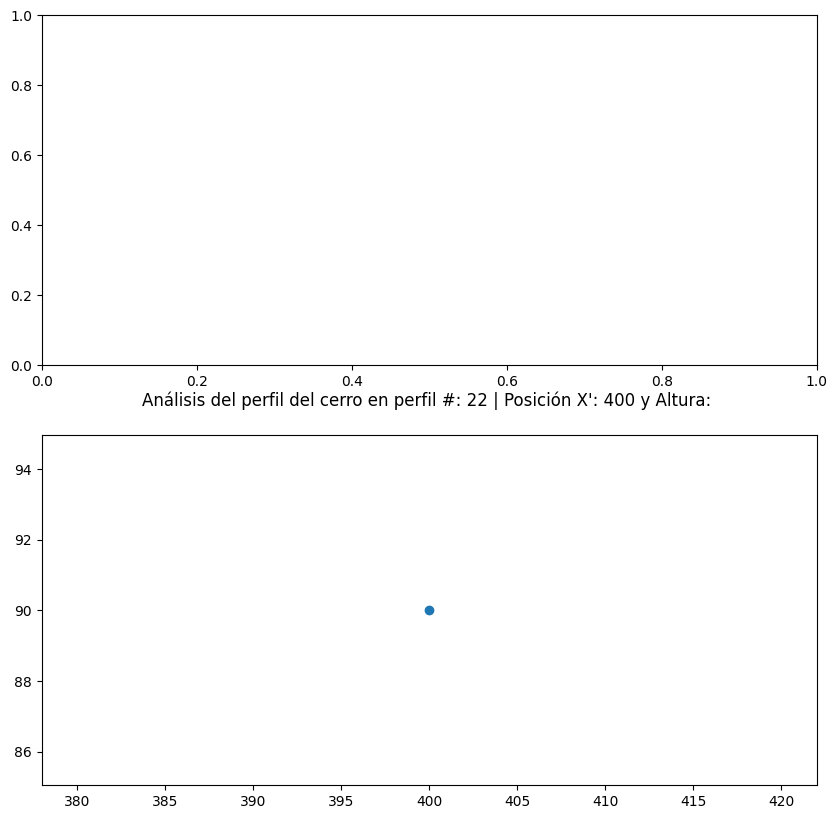

In [16]:
#fig, axs = plt.subplots(1, 5,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3,0.3]})  # 2 filas, 1 columna de subplots
fig, axs = plt.subplots(nrows=2, ncols=1,figsize=(10,10), gridspec_kw={'height_ratios': [1, 1]} )  # 2 filas, 1 columna de subplots
pasos_en_grafica = 30

####################################################################################################
#PLOT 0 del perfil UNI y puntos de intersección 
############ 
axs[1].plot(arr_z_cerro)
axs[1].scatter(pt_ob[0], pt_ob[1])
 
#coordenadas (x,h) de intersección entre la proyección de observación y el perfil del cerro, para cada ángulo analizado
vec_dis=[] #vector con la fila, el ángulo de observación y la profundidad
j=0
p2_max = 0
axs[1].set_title("Análisis del perfil del cerro en perfil #: "+ str(fila)+" | Posición X': "+str(n)+" y Altura: \n") 
 
vec_pts_sup,  vec_angles  , vec_distancia_raster = [] , [], []
index_i = 300 #inicializacion 
for i in range(index_i, len(arr_z_cerro), pasos_en_grafica):  
      
    angulo_m = math.degrees(np.arctan(pendiente_recta(pt_ob, [i, arr_z_cerro[i]])))
     
    if angulo_m < 0: 
       
        angulo_m = angulo_m +180
    
    
    axs[1].plot([pt_ob[0], i],[pt_ob[1], arr_z_cerro[i]])# , color=color[j])    
    axs[1].scatter(i, arr_z_cerro[i]) 
    evento = [fila,round(angulo_m),distancia_d(pt_ob,[i, arr_z_cerro[i]])]  #los valores registrados son azimutales, los valores en el plot son elevación
    vec_dis.append(evento)  # fila, th_i angulo de observación, distancia 
    
    
#######################################################----------------------------#
### Creacion de diccionario 

diccionario = {}  # Inicializar el diccionario vacío
#Recordar que vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves para cada uno de los ángulos
    clave = round(vec_dis[i][1],0) #valores de ángulo
    valor = round(vec_dis[i][2],0) #valores de distancia
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  

    
### Registra distancias para los angulos disponibles 

a_vec_dis=[] #vector con los valores de profundidad desde un punto de observación dado por vec_dis. 
for i in range(len(vec_dis)):
    r = vec_dis[i][2] #registra solo la distancia 
    a_vec_dis.append(np.round(r,0))

a_vec_dis = np.array(a_vec_dis) #registra las distancias de los ángulos disponibles para la observación desde un punto de observación 
a_vec_dis = a_vec_dis[::-1] #ordena de menor a mayor
 


#######################################################----------------------------#
### Vector con los valores de ángulo tomada de vec dis
b_vec_dis=[] #vector con los valores de profundidad tomada de vec_dis
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    rr = vec_dis[i][1] #registra solo los ángulos 
    b_vec_dis.append(np.round(rr,2))

b_vec_dis = np.array(b_vec_dis)
b_vec_dis=b_vec_dis[::-1] 

matriz = np.tile(a_vec_dis, (1,1))
matriz_rotada_distancias_observacion = np.rot90(matriz)

 


########################################################################################################## 
#PLOT 1 de la distancia
############ 

'''
axs[1].set_title("Profundidad (m) \n")
im = axs[1].pcolormesh(matriz_rotada_distancias_observacion,cmap="viridis_r")
for i in range(matriz_rotada_distancias_observacion.shape[0]):
    for j in range(matriz_rotada_distancias_observacion.shape[1]): 
        if i <= 8:         
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), fontweight='bold',  color='black', ha='center', va='center')
        else: 
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), color='white', ha='center', va='center')
'''

 
 
#PLOT 2: Ángulos de observación de ángulos diferente de 0 
############

matriz_2 = np.tile(b_vec_dis, (1,1))
matriz_rotada_angulos_observacion = np.rot90(matriz_2)
'''
axs[2].set_title("Ángulo (°) \n")

io = axs[2].pcolormesh(matriz_rotada_angulos_observacion,cmap="viridis")

for i in range(matriz_rotada_angulos_observacion.shape[0]):
    for j in range(matriz_rotada_angulos_observacion.shape[1]):
        if i <= 5:         
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°', fontweight='bold',color='black', ha='center', va='center')
        else: 
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°',  fontweight='bold',color='black', ha='center', va='center')
'''

################################################
## Cálculo de la atenuación por cada archivo
################################################


#####################################################
########### LOOP SOBRE TODOS LOS ARCHIVOS ###########

veco=[] #array con los valores de phi , theta, distancia recorrida, Einicial, Efinal, Control
angulos_atenuados = []
veco_tesis  = []

 


conteo_archivo = 0 
# Recorremos todos los archivos en el directorio
for nombre_archivo in os.listdir(directorio):
    # Construimos la ruta completa al archivo
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    conteo_archivo= conteo_archivo+1
    
    # Verificamos si es un archivo (y no una carpeta)
    if os.path.isfile(ruta_archivo):
        # Abrimos y leemos el archivo 

        with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
             # Aquí puedes procesar el contenido como necesites 

            df_shower  = pd.read_csv(ruta_archivo, sep =" ")# Lee los datos del shower en energia y ángulo
            data_shower = df_shower.sort_values(by=df_shower.columns[1]) #data ordered by phi angle
            dfshower_pre_filtrado = data_shower[ (data_shower['phit'] >= phi1) & (data_shower['phit'] <= phi2)] #data selected by phi angle limits
            dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 
            conteo_evento = 0 

            for j in range(len(dfshower_filtrado)):  
                #if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
                angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
                temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
                temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
                    
                temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################
            
                 
                fin_ener, val_temp = perdida_energia_total(temp_energia_shower, np.round(temp_distancia_x_angulo,0)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
                res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
                veco.append(res_atenua)
                    
                    
                conteo_evento = conteo_evento +1       

    #print("# de archivo", conteo_archivo)

print("Total de archivos procesados = ", conteo_archivo) 
print("# de eventos = ", conteo_evento) 

print("=============") 

#######################################################----------------------------#
### Grafica final de Plot 0

texto = '\nPasos: '+ str(j) +'\n # de eventos: '+ str(len(veco))
x_pos = 130 # valor 20 de posición de texto en X
y_pos = np.max(arr_z_cerro) -10 # valor de posición de caja de texto en Y 
axs[1].text(x_pos, y_pos, texto,fontsize = '12', bbox=dict(facecolor='white', edgecolor='black', linewidth=1))
axs[1].set_xlim(100,650) 
axs[1].legend(loc="center left", bbox_to_anchor=(-0.2, 0.5))  # Ajustar la posición con bbox_to_anchor
# Títulos y etiquetas
axs[1].set_title("Gráfico con leyenda en el eje Y")
axs[1].set_xlabel("Eje X")
axs[1].set_ylabel("Altura (m.s.n.m)")

#axs[0].set_ylim(110, np.max(arr_z_cerro)+20)


########### END LOOP SOBRE TODOS LOS ARCHIVOS ###########
#########################################################

#################
#Pérdida de energía de acuerdo a Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

## Reducir los valores ###
 
vector_reducido = reducir_vector_por_media(vec_atenuado)

 


################################################
## Fin del cálculo de la atenuación
################################################
## Calculamos el porcentaje de atenuación

data_porcentaje = np.array(vec_angle)

########################################################################################################## 
#PLOT 3
############
data_angle = np.array(vector_reducido)
data_angle=data_angle[::-1] 
matriz_3 = np.tile(data_angle, (1,1))
matriz_rotada_3 = matriz_3
matriz_rotada_3 = np.rot90(matriz_3) 
 
 
##Crear listas de datos para ambas franjas semicirculares
data_angle1 = data_angle  # Datos para la transmitancia 
data_angle2 = b_vec_dis  # Datos para los ángulos
data_angle3 = a_vec_dis  # Datos para las distancias 

n_points = len(data_angle1)  # Número de puntos

# Ángulos y radios de ambas franjas
angles = np.linspace(0, np.pi, n_points)  # Ángulos del semicírculo
radius_inner1, radius_outer1 = 0.6, 0.7  # Radio interior y exterior del primer semicírculo
radius_inner2, radius_outer2 = 0.9, 1.0  # Radio interior y exterior del segundo semicírculo
radius_inner3, radius_outer3 = 1.2, 1.3  # Radio interior y exterior del segundo semicírculo



# Generar datos para el primer semicírculo
X1, Y1, Z1 = generate_semicircle_data(radius_inner1, radius_outer1, data_angle1)
# Generar datos para el segundo semicírculo
X2, Y2, Z2 = generate_semicircle_data(radius_inner2, radius_outer2, data_angle2)
# Generar datos para el segundo semicírculo
X3, Y3, Z3 = generate_semicircle_data(radius_inner3, radius_outer3, data_angle3)


# Visualización
#axs.set_title("Franjas Semicirculares Superpuestas con Texto Condicionado \n")

# Dibujar el primer semicírculo
axs[0].pcolormesh(X1, Y1, Z1, cmap="viridis_r", shading="auto")
# Dibujar el segundo semicírculo
axs[0].pcolormesh(X2, Y2, Z2, cmap="plasma", shading="auto")  
# Dibujar el segundo semicírculo
axs[0].pcolormesh(X3, Y3, Z3, cmap="plasma", shading="auto")  
# Función para determinar el color del texto
def get_text_color(value, threshold=40):
    return "white" if value < threshold else "black"


# Eliminar las dimensiones (ejes) del subplot
axs[0].set_xticks([])  # Quitar marcas en el eje X
axs[0].set_yticks([])  # Quitar marcas en el eje Y
axs[0].set_xticklabels([])  # Quitar etiquetas en el eje X
axs[0].set_yticklabels([])  # Quitar etiquetas en el eje Y

# También puedes eliminar los bordes del gráfico para mayor limpieza
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].spines['left'].set_visible(False)


# Agregar texto al primer semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid1 = (radius_inner1 + radius_outer1) / 2
    x_text1 = radius_mid1 * np.cos(angle)
    y_text1 = radius_mid1 * np.sin(angle)
    color = get_text_color(data_angle1[i])
    axs[0].text(x_text1, y_text1, f"{data_angle1[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')
# Agregar texto al segundo semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid2 = (radius_inner2 + radius_outer2) / 2
    x_text2 = radius_mid2 * np.cos(angle)
    y_text2 = radius_mid2 * np.sin(angle)
    color = get_text_color(data_angle2[i])
    axs[0].text(x_text2, y_text2, f"{data_angle2[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')

# Agregar texto al segundo semicírculo
for i in range(n_points):
    angle = angles[i]
    radius_mid3 = (radius_inner3 + radius_outer3) / 2
    x_text3 = radius_mid3 * np.cos(angle)
    y_text3 = radius_mid3 * np.sin(angle)
    color = get_text_color(data_angle2[i])
    axs[0].text(x_text3, y_text3, f"{data_angle3[i]:.0f}", color=color, fontsize=8, 
             ha="center", va="center", rotation=np.degrees(angle) - 90, fontweight='bold')


#falta filtrar por ángulo phi 
#df_shower es donde hay que trabajarlo

#plt.savefig("Análisis del perfil del cerro en X_"+str(n)+ "_Z_"+ str(m)+ "_Y_"+ str(fila)+".png" )
plt.savefig("Análisis desde interior perfil del cerro en X_"+str(n)+ "_Z_"+ str(m)+ "_Y_"+ str(fila)+".png" )

plt.show()



In [ ]:
#################
#Pérdida de energía de acuerdo a Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

## Reducir los valores ###
 

In [11]:
df_atenuado

,phi,theta,distancia,Energia_i,Energia_f,Control
0,269.0,60,161.0,3.998114,77.015034,True
1,269.0,55,161.0,6.400277,249.641724,True
2,269.0,58,161.0,7.143085,287.597937,True
3,269.0,41,247.0,2.074268,-3.356565,False
4,269.0,61,161.0,1.741204,-1.923047,False
...,...,...,...,...,...,...
1984305,271.0,18,423.0,2.820191,-1.626813,False
1984306,271.0,30,334.0,3.145568,-0.188413,False
1984307,271.0,70,95.0,2.899362,531.131299,True
1984308,271.0,68,95.0,0.467283,-0.517358,False


In [32]:


diccionario = {}  # Inicializar el diccionario vacío
#Recordar que vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves para cada uno de los ángulos
    clave = round(vec_dis[i][1],0) #valores de ángulo
    valor = round(vec_dis[i][2],0) #valores de distancia
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  

for j in range(len(dfshower_filtrado)):  
    #if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
    angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
    temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
    temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
                    
    temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################
            
                 
    fin_ener, val_temp = perdida_energia_total(temp_energia_shower, round(temp_distancia_x_angulo,0))#Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
    res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
    veco.append(res_atenua)
                    

TypeError: type NoneType doesn't define __round__ method

In [33]:
acceder_diccionario(diccionario, temp_angulo_shower)

In [35]:
vec_dis

[]